# Traffic Object Detection: Phase 1 Preprocessing

## 1. Dataset Description and Features
**Dataset:** A curated subset of the BDD100K dataset, formatted in YOLOv8 structure via Roboflow. It focuses on diverse traffic scenarios (varying weather, lighting, and times of day) for autonomous driving and traffic monitoring.

**Features:**
In the YOLO format, labels are stored in `.txt` files corresponding to each image. The features for each detected object (row) are:
* `class_id` (Categorical): The integer representing the object type (e.g., 0 for Pedestrian, 2 for Car).
* `center_x` (Numerical): The normalized horizontal center point of the bounding box (0.0 to 1.0).
* `center_y` (Numerical): The normalized vertical center point of the bounding box (0.0 to 1.0).
* `width` (Numerical): The normalized width of the bounding box.
* `height` (Numerical): The normalized height of the bounding box.

### BDD100K Subset Class Mapping

| Class ID | Object Category | Description |
| :---: | :--- | :--- |
| **0** | Car | Standard passenger vehicles, SUVs, and vans |
| **1** | Pedestrian | Any person walking or standing near the road |
| **2** | Traffic Light | Illuminated traffic control signals |
| **3** | Traffic Sign | Street signs, stop signs, and speed limits |

## Preprocessing with Pandas

This section covers:
* Imported libraries
* Loaded YOLO data
* Checked missing values *(None found)*
* Checked dimensionality
* Calculated descriptive statistics

In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import display

labels_dir = Path("../data/train/labels")
parsed_data = []

for txt_file in labels_dir.glob("*.txt"):
    with open(txt_file, "r") as file:
        for line in file.readlines():
            parts = line.strip().split()
            if len(parts) == 5:
                parsed_data.append({
                    "class_id": int(parts[0]),
                    "center_x": float(parts[1]),
                    "center_y": float(parts[2]),
                    "width": float(parts[3]),
                    "height": float(parts[4])
                })

df = pd.DataFrame(parsed_data)

df['class_id'] = df['class_id'].astype('category')

print("Missing values in dataset:")
print(df.isnull().sum())

print(f"\nDataFrame Shape: {df.shape}")
print("\nDescriptive Statistics for Bounding Boxes:")
display(df.describe())

Missing values in dataset:
class_id    0
center_x    0
center_y    0
width       0
height      0
dtype: int64

DataFrame Shape: (140919, 5)

Descriptive Statistics for Bounding Boxes:


,center_x,center_y,width,height
count,140919.000000,140919.000000,140919.000000,140919.000000
mean,0.462460,0.455842,0.041947,0.065845
std,0.224527,0.136212,0.055870,0.078496
min,0.001563,0.003125,0.002344,0.003906
25%,0.311719,0.378125,0.012500,0.023438
50%,0.457813,0.459375,0.021875,0.039062
75%,0.600000,0.539062,0.044531,0.073438
max,0.997656,0.992969,0.857031,0.996875


## Outlier Analysis

In [6]:
print("Outlier Analysis")

Q1_w = df['width'].quantile(0.25)
Q3_w = df['width'].quantile(0.75)
IQR_w = Q3_w - Q1_w
lower_bound_w = Q1_w - 1.5 * IQR_w
upper_bound_w = Q3_w + 1.5 * IQR_w

Q1_h = df['height'].quantile(0.25)
Q3_h = df['height'].quantile(0.75)
IQR_h = Q3_h - Q1_h
lower_bound_h = Q1_h - 1.5 * IQR_h
upper_bound_h = Q3_h + 1.5 * IQR_h

outliers = df[
    (df['width'] < lower_bound_w) | (df['width'] > upper_bound_w) |
    (df['height'] < lower_bound_h) | (df['height'] > upper_bound_h)
]

print(f"Total objects analyzed: {len(df)}")
print(f"Found {len(outliers)} outlier bounding boxes based on width AND/OR height.")
print(f"Percentage of dataset flagged as outliers: {(len(outliers)/len(df))*100:.2f}%\n")


Outlier Analysis
Total objects analyzed: 140919
Found 17799 outlier bounding boxes based on width AND/OR height.
Percentage of dataset flagged as outliers: 12.63%



### Strategy to Handle Outliers

In the context of dashcam footage, statistical 'outliers' in width/height
typically represent vehicles that are extremely close to the camera (massive boxes)
or very far away on the horizon (tiny boxes).
Strategy: We will KEEP these outliers in the dataset rather than removing them.
Removing them would artificially blind the model to objects at extreme distances,
which is critical for a robust traffic detection system.

# Data Visualizations

### 1. Categorical Features: Bar Chart
It visualizes the frequency of each object class, which is crucial for identifying any class imbalancesin the dataset.

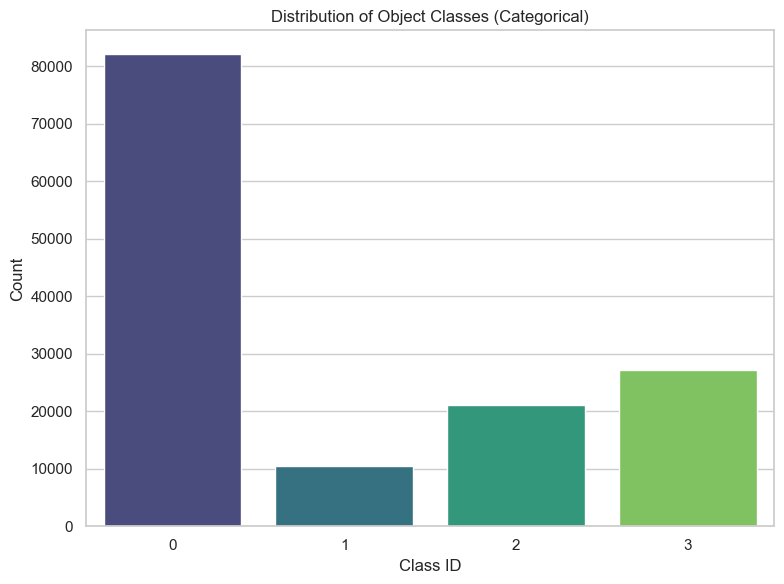

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

sns.countplot(data=df, x='class_id', hue='class_id', palette="viridis", legend=False)
plt.title("Distribution of Object Classes (Categorical)")
plt.xlabel("Class ID")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### 2. Numerical Features: Histogram
It displays the distribution of bounding box widths. The added Kernel Density Estimate (KDE) line helps visualize the shape of data and identify the most common object sizes.

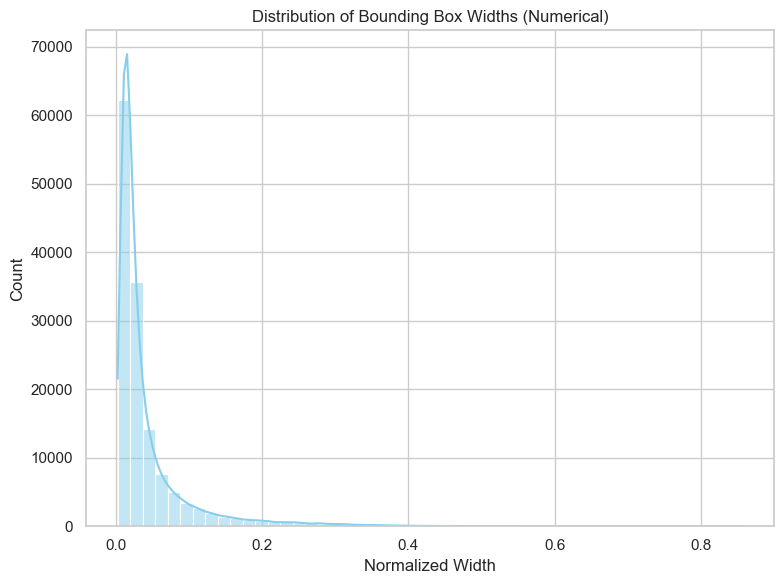

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

sns.histplot(data=df, x='width', bins=50, color="skyblue", kde=True)
plt.title("Distribution of Bounding Box Widths (Numerical)")
plt.xlabel("Normalized Width")

plt.tight_layout()
plt.show()

### 3. Numerical Features: Boxplot
It breaks down the bounding box heights by their specific class. It is the perfect visual representation of IQR outlier math, clearly showing the median, quartiles, and extreme outliers.

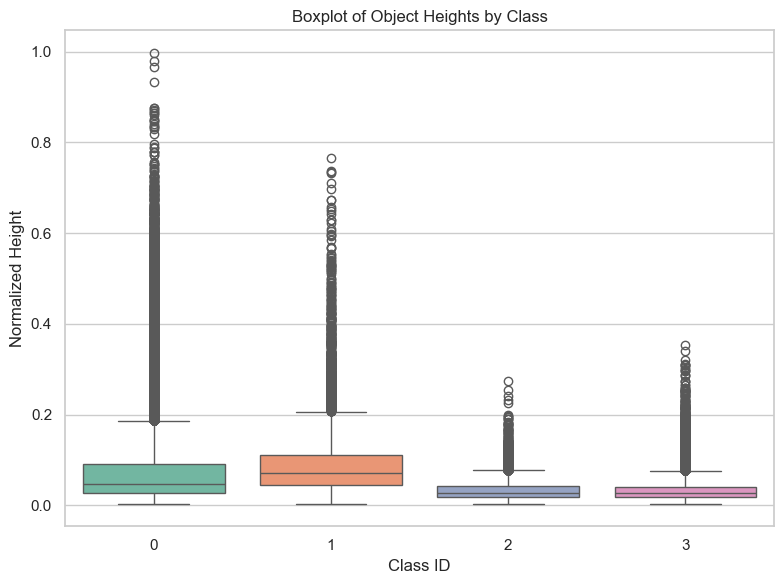

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

sns.boxplot(data=df, x='class_id', y='height', hue='class_id', palette="Set2", legend=False)
plt.title("Boxplot of Object Heights by Class")
plt.xlabel("Class ID")
plt.ylabel("Normalized Height")

plt.tight_layout()
plt.show()

### 4. Relationships: Scatter Plot & Pairplot
It maps the width versus height for individual objects, followed by a multi-dimensional matrix of all features mapped against each other.

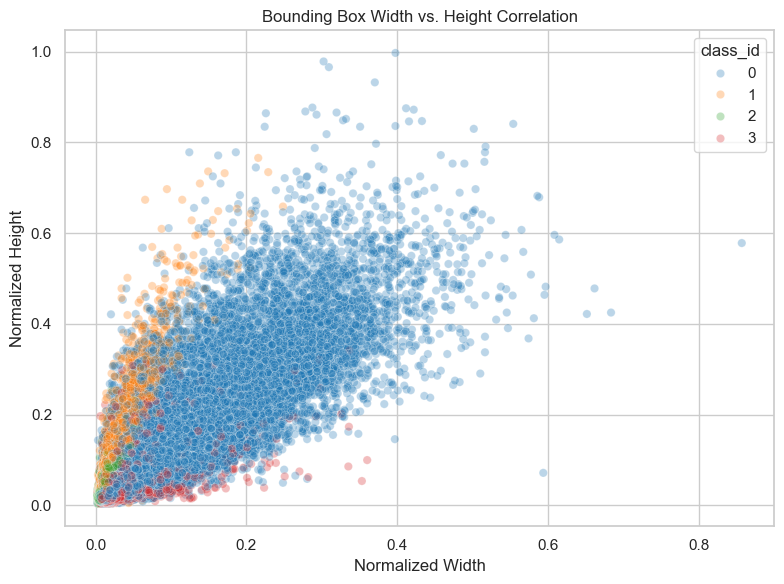

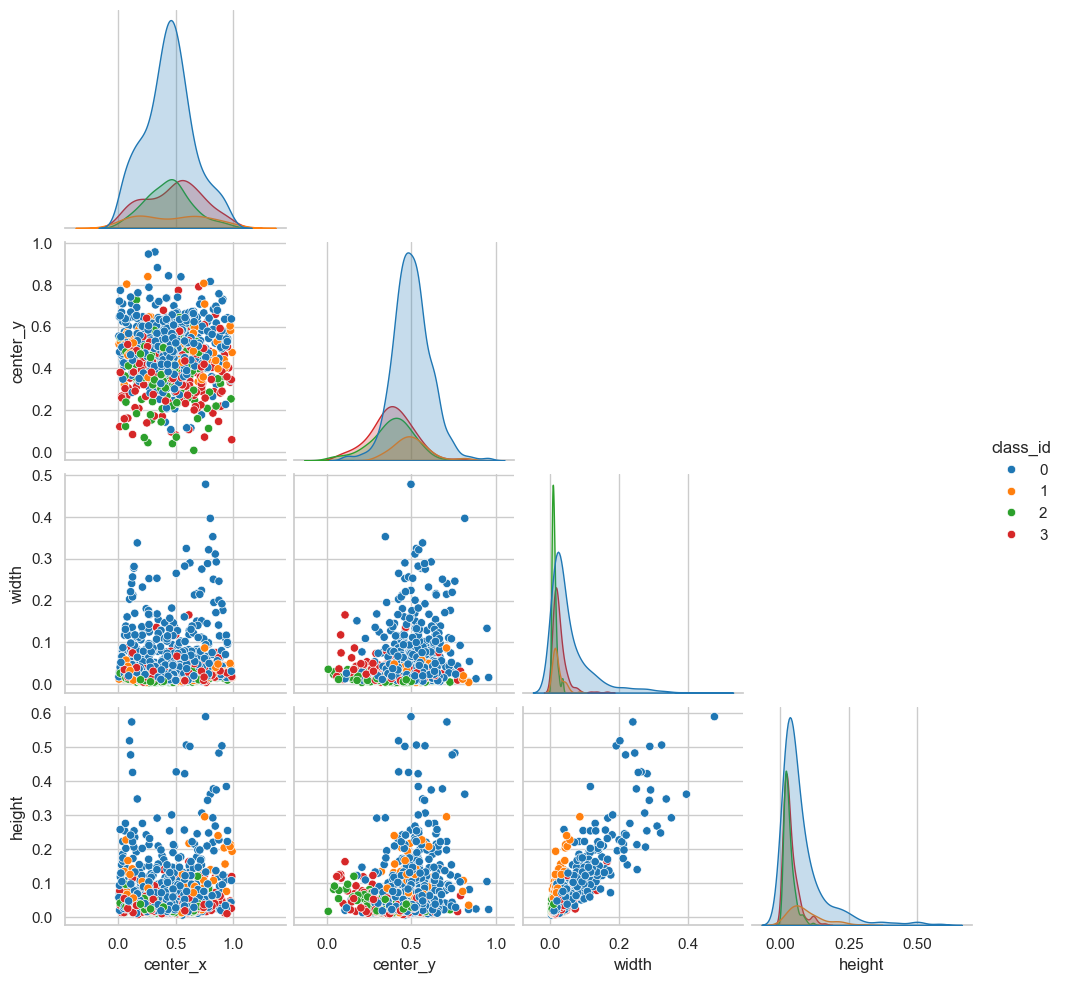

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='width', y='height', hue='class_id', alpha=0.3, palette="tab10")
plt.title("Bounding Box Width vs. Height Correlation")
plt.xlabel("Normalized Width")
plt.ylabel("Normalized Height")
plt.tight_layout()
plt.show()

sampled_df = df.sample(n=1000, random_state=42)
sns.pairplot(sampled_df[['center_x', 'center_y', 'width', 'height', 'class_id']], hue='class_id', palette="tab10", corner=True)
plt.show()